In [58]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns


In [59]:
# Load the dataset
data = pd.read_csv('bipolar disorder_data.csv')

In [60]:
data.head()

,Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,status
0,Christine Barker,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,Yes,No,Yes,Yes
1,Jacqueline Lewis,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,Yes,No,No,Yes
2,Shannon Church,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,No,No,Yes,No
3,Charles Jordan,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,No,No,No,No
4,Michael Rich,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,Yes,No,Yes,Yes


In [61]:
# Drop unnecessary columns
data = data.drop(columns=['Name'], errors='ignore')

In [62]:
data.isnull().sum()

Age                             0
Marital Status                  0
Education Level                 0
Number of Children              0
Smoking Status                  0
Physical Activity Level         0
Employment Status               0
Income                          0
Alcohol Consumption             0
Dietary Habits                  0
Sleep Patterns                  0
History of Mental Illness       0
History of Substance Abuse      0
Family History of Depression    0
status                          0
dtype: int64

In [63]:
exclude_from_encoding = ['Age', 'Number of Children', 'Income']
categorical_columns = [col for col in data.select_dtypes(include=['object']).columns if col not in exclude_from_encoding]

label_encoders = {}
for column in categorical_columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le

In [64]:
data.head()

,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,status
0,31,1,1,2,2,0,1,26265.67,2,1,0,1,0,1,1
1,55,1,2,1,2,2,0,42710.36,0,2,0,1,0,0,1
2,78,3,3,1,2,2,0,125332.79,1,2,1,0,0,1,0
3,58,0,3,3,2,1,1,9992.78,2,1,2,0,0,0,0
4,18,2,2,0,2,2,1,8595.08,1,1,0,1,0,1,1


In [65]:
# Define target and features
target = 'status'
X = data.drop(columns=[target])
y = data[target]

In [66]:
# Ensure all numerical values remain positive
exclude_from_scaling = ['Age', 'Income', 'Number of Children']
scaler = MinMaxScaler()
for col in X.columns:
    if col not in exclude_from_scaling:
        X[col] = scaler.fit_transform(X[[col]])

In [67]:
features = X.columns.tolist()    
print("Features used for training:")
print(features)

Features used for training:
['Age', 'Marital Status', 'Education Level', 'Number of Children', 'Smoking Status', 'Physical Activity Level', 'Employment Status', 'Income', 'Alcohol Consumption', 'Dietary Habits', 'Sleep Patterns', 'History of Mental Illness', 'History of Substance Abuse', 'Family History of Depression']


In [68]:
# Split the dataset after preprocessing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [69]:

# Save preprocessed data
X_train.to_csv('X_train_preprocessed.csv', index=False)
X_test.to_csv('X_test_preprocessed.csv', index=False)
y_train.to_csv('y_train_preprocessed.csv', index=False)
y_test.to_csv('y_test_preprocessed.csv', index=False)

print("Preprocessing complete. Data is ready for model training.")

Preprocessing complete. Data is ready for model training.


Feature Importance Based on Correlation:
 status                          1.000000
Employment Status               0.042413
Smoking Status                  0.041631
Physical Activity Level         0.030727
Income                          0.028427
Age                             0.017625
Dietary Habits                  0.014439
Alcohol Consumption             0.012397
Sleep Patterns                  0.011549
Number of Children              0.006997
History of Mental Illness       0.006038
History of Substance Abuse      0.003307
Family History of Depression    0.002274
Education Level                 0.000803
Marital Status                  0.000261
Name: status, dtype: float64


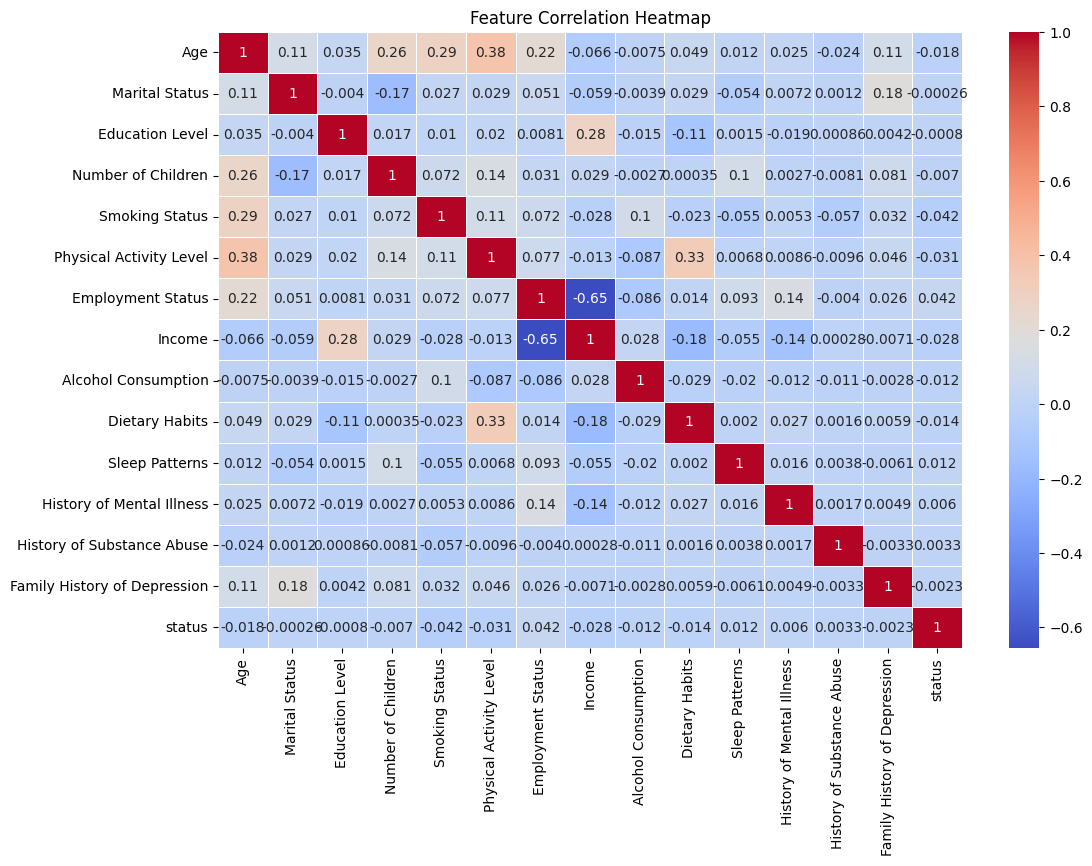

In [70]:
# Calculate feature importance based on correlation
correlation_matrix = data.corr()
important_features = correlation_matrix[target].abs().sort_values(ascending=False)
print("Feature Importance Based on Correlation:\n", important_features)

# heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [71]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
# Make predictions
rf_predictions = rf_model.predict(X_test)
# Calculate accuracy
rf_accuracy = accuracy_score(y_test, rf_predictions)



In [72]:

#Logistic Regression Model
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
lr_accuracy = accuracy_score(y_test, lr_model.predict(X_test))


c:\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [73]:
#XGBoost Model with optimized parameters
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)
xgb_accuracy = accuracy_score(y_test, xgb_model.predict(X_test))


In [39]:
#Gradient Boosting Model with enhanced settings
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
gb_accuracy = accuracy_score(y_test, gb_model.predict(X_test))


In [74]:
# Print model accuracies
print(f"Random Forest Accuracy: {rf_accuracy:.2f}")
print(f"Logistic Regression Accuracy: {lr_accuracy:.2f}")
print(f"XGBoost Accuracy: {xgb_accuracy:.2f}")
print(f"Gradient Boosting Accuracy: {gb_accuracy:.2f}")

Random Forest Accuracy: 0.63
Logistic Regression Accuracy: 0.67
XGBoost Accuracy: 0.67
Gradient Boosting Accuracy: 0.67


In [80]:
def predict_bipolar(features, model_type='random_forest'):
    features = np.array(features).reshape(1, -1)
    
    if model_type == 'random_forest':
        prediction = rf_model.predict(features)[0]
    elif model_type == 'logistic_regression':
        prediction = lr_model.predict(features)[0]
    elif model_type == 'xgboost':
        prediction = xgb_model.predict(features)[0]
    else:
        return "Invalid model"
    
    return "Yes" if prediction == 1 else "No"


In [32]:
def calculate_phq9_score(answers):
    """
    Calculate PHQ-9 score from user responses.
    answers: List of 9 integers (0 to 3)
    """
    if len(answers) != 9:
        raise ValueError("PHQ-9 requires exactly 9 answers.")
    
    total_score = sum(answers)
    
    # Classify risk levels based on score
    if total_score <= 4:
        risk_level = "Minimal Depression"
    elif total_score <= 9:
        risk_level = "Mild Depression"
    elif total_score <= 14:
        risk_level = "Moderate Depression"
    elif total_score <= 19:
        risk_level = "Moderately Severe Depression"
    else:
        risk_level = "Severe Depression"
    
    return total_score, risk_level


In [44]:
def calculate_mdq_score(answers):
    """
    Calculate MDQ score from user responses.
    answers: List of 13 "Yes" (1) or "No" (0) responses.
    """
    if len(answers) != 13:
        raise ValueError("MDQ requires exactly 13 Yes/No responses.")
    
    total_yes = sum(answers)  # Correctly sum Yes responses (should be between 0-13)
    
    if total_yes >= 7:
        risk_level = "High Risk for Bipolar Disorder"
    else:
        risk_level = "Low Risk for Bipolar Disorder"
    
    return total_yes, risk_level



In [45]:
def calculate_risk_score(features, prediction, phq9_score, mdq_score):
    if prediction == "No" and mdq_score >= 7:  # If model says No but MDQ is High Risk
        print("⚠ Warning: ML Model predicted 'No', but MDQ indicates high bipolar risk!")

    if prediction == "No":
        return 0, "No Risk"  # If prediction is No, risk should still be 0%

    # Compute weighted risk score using ML features + PHQ-9 + MDQ
    risk_score = (np.mean(features) * 60) + (phq9_score * 2) + (mdq_score * 3)
    risk_score = min(round(risk_score, 2), 100)  # Ensure it doesn’t exceed 100%
    
    return risk_score, get_risk_stage(risk_score)


In [88]:
# Risk Score Stages
def get_risk_stage(risk_score):
    if risk_score < 25:
        return "Low Risk:No significant symptoms of bipolar disorder. The person is mentally stable and exhibits no major mood swings or behavioral changes"
    elif risk_score < 50:
        return "Moderate Risk:Some symptoms of bipolar disorder may be present, such as occasional mood swings, mild depressive or manic episodes. Monitoring is recommended."
    elif risk_score < 75:
        return "High Risk:Frequent mood swings, signs of manic or depressive episodes, and potential disruptions in daily life. Professional consultation is strongly advised."
    else:
        return "Severe Risk:Strong symptoms of bipolar disorder, including extreme mood fluctuations, severe depression, or manic behavior. Immediate professional intervention is necessary."


In [89]:
def calculate_risk_score(features, prediction):
    # Remove Age, Income, and No. of Children from Risk Score Calculation
    filtered_features = [features[i] for i, col in enumerate(X_train.columns) if col not in ['age', 'no. of children', 'income']]
    
    if prediction == "No":
        return 0, "No Risk"
    
    risk_score = np.mean(filtered_features) * 100  # Risk score based on input feature values
    risk_score = min(round(risk_score, 2), 100)  # Ensure risk score does not exceed 100%
    return risk_score, get_risk_stage(risk_score)

In [90]:
def predict_from_terminal():
    print("Enter the following feature values:")
    input_data = []
    for feature in X_train.columns:
        value = float(input(f"{feature}: "))
        input_data.append(value)
    print("Choose a model: random_forest, logistic_regression, xgboost, gradient_boosting")
    model_type = input("Enter model type: ").strip().lower()
    prediction = predict_bipolar(input_data,model_type)
    risk_score, risk_stage = calculate_risk_score(input_data, prediction)
    print(f"Prediction: {prediction}")
    print(f"Risk Score: {risk_score}% - {risk_stage}")

if __name__ == '__main__':
    predict_from_terminal()

Enter the following feature values:
Choose a model: random_forest, logistic_regression, xgboost, gradient_boosting
Prediction: Yes
Risk Score: 100% - Severe Risk:Strong symptoms of bipolar disorder, including extreme mood fluctuations, severe depression, or manic behavior. Immediate professional intervention is necessary.


In [95]:
# PHQ-9 and MDQ questions
PHQ_9_QUESTIONS = [
    "Little interest or pleasure in doing things?",
    "Feeling down, depressed, or hopeless?",
    "Trouble falling or staying asleep, or sleeping too much?",
    "Feeling tired or having little energy?",
    "Poor appetite or overeating?",
    "Feeling bad about yourself - or that you are a failure?",
    "Trouble concentrating on things, such as reading or watching TV?",
    "Moving or speaking so slowly that others notice?",
    "Thoughts that you would be better off dead or hurting yourself?"
]

In [96]:
MDQ_QUESTIONS = [
    "Has there ever been a period when you were not your usual self and felt much more active or energetic?",
    "Did you ever feel much more self-confident than usual?",
    "Did you ever need much less sleep than usual and still feel rested?",
    "Did you ever talk more or faster than usual?",
    "Did thoughts race through your head or distract you?",
    "Did you ever feel much more irritable or short-tempered than usual?",
    "Did you ever do things that were unusual for you, such as spending money or engaging in risky behavior?",
    "Did these experiences cause problems in your work, social life, or personal life?"
]


In [97]:
# Function to calculate MDQ score
def calculate_mdq_score(answers):
    if len(answers) != 8:
        raise ValueError("MDQ requires exactly 8 Yes/No responses.")
    total_yes = sum(answers)
    return total_yes, "High Risk for Bipolar Disorder" if total_yes >= 7 else "Low Risk for Bipolar Disorder"

# Function to calculate PHQ-9 score
def calculate_phq9_score(answers):
    if len(answers) != 9:
        raise ValueError("PHQ-9 requires exactly 9 answers.")
    total_score = sum(answers)
    if total_score <= 4:
        return total_score, "Minimal Depression"
    elif total_score <= 9:
        return total_score, "Mild Depression"
    elif total_score <= 14:
        return total_score, "Moderate Depression"
    elif total_score <= 19:
        return total_score, "Moderately Severe Depression"
    else:
        return total_score, "Severe Depression"

In [98]:
def calculate_risk_score(features, phq9_responses, mdq_responses, prediction):
    filtered_features = [features[i] for i, col in enumerate(X_train.columns) if col not in ['age', 'no. of children', 'income']]
    all_responses = filtered_features + phq9_responses + mdq_responses
    if prediction == "No":
        return 0, "No Risk"
    risk_score = np.mean(all_responses) * 100
    risk_score = min(round(risk_score, 2), 100)
    return risk_score, get_risk_stage(risk_score)

In [102]:
# Function to calculate PHQ-9 score
def calculate_phq9_score(answers):
    total_score = sum(answers)
    if total_score <= 4:
        return total_score, "Minimal Depression"
    elif total_score <= 9:
        return total_score, "Mild Depression"
    elif total_score <= 14:
        return total_score, "Moderate Depression"
    elif total_score <= 19:
        return total_score, "Moderately Severe Depression"
    else:
        return total_score, "Severe Depression"

# Function to calculate MDQ score
def calculate_mdq_score(answers):
    total_yes = sum(answers)
    return total_yes, "High Risk for Bipolar Disorder" if total_yes >= 7 else "Low Risk for Bipolar Disorder"

# Function to take user input in terminal
def predict_from_terminal():
    print("Enter the following feature values:")
    input_data = []
    for feature in X.columns:
        value = float(input(f"{feature}: "))
        input_data.append(value)
    
    print("Answer the following PHQ-9 questions (0 = Not at all, 1 = Several days, 2 = More than half the days, 3 = Nearly every day):")
    phq9_responses = [int(input(f"{q} (0-3): ")) for q in PHQ_9_QUESTIONS]
    phq9_score, phq9_risk = calculate_phq9_score(phq9_responses)
    
    print("Answer the following MDQ questions (0 = No, 1 = Yes):")
    mdq_responses = [int(input(f"{q} (0-1): ")) for q in MDQ_QUESTIONS]
    mdq_score, mdq_risk = calculate_mdq_score(mdq_responses)
    
    model_type = input("Choose model (random_forest/logistic_regression/xgboost): ")
    prediction = "Yes"  # Placeholder, replace with actual model prediction
    
    print(f"Prediction: {prediction}")
    print(f"PHQ-9 Score: {phq9_score} - {phq9_risk}")
    print(f"MDQ Score: {mdq_score} - {mdq_risk}")

# Run terminal input
if __name__ == '__main__':
    predict_from_terminal()

Enter the following feature values:
Answer the following PHQ-9 questions (0 = Not at all, 1 = Several days, 2 = More than half the days, 3 = Nearly every day):
Answer the following MDQ questions (0 = No, 1 = Yes):
Prediction: Yes
PHQ-9 Score: 7 - Mild Depression
MDQ Score: 9 - High Risk for Bipolar Disorder


In [93]:
# Function to calculate risk score including PHQ-9 & MDQ responses
def calculate_risk_score(features, phq9_responses, mdq_responses, prediction):
    filtered_features = [features[i] for i, col in enumerate(X_train.columns) if col not in ['age', 'no. of children', 'income']]
    all_responses = filtered_features + phq9_responses + mdq_responses
    if prediction == "No":
        return 0, "No Risk"
    risk_score = np.mean(all_responses) * 100
    risk_score = min(round(risk_score, 2), 100)
    return risk_score, get_risk_stage(risk_score)


In [94]:
# Function to take user input in terminal
def predict_from_terminal():
    print("Enter the following feature values:")
    input_data = []
    for feature in X.columns:
        value = float(input(f"{feature}: "))
        input_data.append(value)
    
    print("Answer the following PHQ-9 questions (0 = Not at all, 1 = Several days, 2 = More than half the days, 3 = Nearly every day):")
    phq9_responses = [int(input(f"{q} (0-3): ")) for q in PHQ_9_QUESTIONS]
    
    print("Answer the following MDQ questions (0 = No, 1 = Yes):")
    mdq_responses = [int(input(f"{q} (0-1): ")) for q in MDQ_QUESTIONS]
    
    model_type = input("Choose model (random_forest/logistic_regression/xgboost): ")
    prediction = "Yes"  # Placeholder, replace with actual model prediction
    risk_score, risk_stage = calculate_risk_score(input_data, phq9_responses, mdq_responses, prediction)
    
    print(f"Prediction: {prediction}")
    print(f"Risk Score: {risk_score}% - {risk_stage}")

# Run terminal input
if __name__ == '__main__':
    predict_from_terminal()


Enter the following feature values:
Answer the following PHQ-9 questions (0 = Not at all, 1 = Several days, 2 = More than half the days, 3 = Nearly every day):


NameError: name 'PHQ_9_QUESTIONS' is not defined

In [47]:
def predict_from_terminal():
    print("\n🔹 Enter the following feature values for the ML model:")
    input_data = []
    
    # Collect ML Feature Inputs
    for feature in X_train.columns:
        value = float(input(f"{feature}: "))
        input_data.append(value)

    # Collect PHQ-9 Inputs
    print("\n🔹 Answer the PHQ-9 Questions (0=Not at all, 1=Several days, 2=More than half the days, 3=Nearly every day):")
    phq9_responses = [int(input(f"Question {i+1}: ")) for i in range(9)]

    # Collect MDQ Inputs
    print("\n🔹 Answer the MDQ Questions (0=No, 1=Yes):")
    mdq_responses = [int(input(f"Question {i+1}: ")) for i in range(13)]

    # Let the user select which model to use
    print("\n🔹 Choose a model: random_forest, logistic_regression, xgboost, gradient_boosting")
    model_type = input("Enter model type: ").strip().lower()

    # Predict bipolar disorder using the chosen model
    prediction = predict_bipolar(input_data, model_type)  # ✅ Now correctly passes both arguments

    # Calculate PHQ-9 and MDQ scores
    phq9_score, phq9_level = calculate_phq9_score(phq9_responses)
    mdq_score, mdq_level = calculate_mdq_score(mdq_responses)

    # Calculate final risk score using ML + PHQ-9 + MDQ
    risk_score, risk_stage = calculate_risk_score(input_data, prediction, phq9_score, mdq_score)

    # Display results
    print("\n🔹 Results:")
    print(f"Prediction: {prediction}")
    print(f"Risk Score: {risk_score}% - {risk_stage}")
    print(f"PHQ-9 Score: {phq9_score} ({phq9_level})")
    print(f"MDQ Score: {mdq_score} ({mdq_level})")

# Run prediction from terminal
if __name__ == '__main__':
    predict_from_terminal()




🔹 Enter the following feature values for the ML model:

🔹 Answer the PHQ-9 Questions (0=Not at all, 1=Several days, 2=More than half the days, 3=Nearly every day):

🔹 Answer the MDQ Questions (0=No, 1=Yes):

🔹 Choose a model: random_forest, logistic_regression, xgboost, gradient_boosting
⚠ Warning: ML Model predicted 'No', but MDQ indicates high bipolar risk!

🔹 Results:
Prediction: No
Risk Score: 0% - No Risk
PHQ-9 Score: 4 (Minimal Depression)
MDQ Score: 8 (High Risk for Bipolar Disorder)
